Notebook specifically meant to compare models

In [ ]:
from escripts import eplots
from escripts import eMCMC
from escripts import edata
import dataframe_image as dfi
import zeus21

In [14]:
fit_labels = [r'$d\sigma_{\rm{UV}}/dz$', r'Add $d\epsilon_{\star}/dz$', r'Add $d\log M_{\rm{c}}/dz$']

In [126]:
# Get data
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
               '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['Bouwens+21', 'Donnan+24']
sorted_data = edata.get_sorted(file_names, data_labels)

# Initialize parameters
param_dicts = []
param_dicts.append(eMCMC.build_param_data({'dsigdz':{'fit':True}}))
param_dicts.append(eMCMC.build_param_data({'dsigdz':{'fit':True}, 'dlogedz':{'fit':True}}))
param_dicts.append(eMCMC.build_param_data({'dsigdz':{'fit':True}, 'dlogMcdz':{'fit':True}}))

In [127]:
file_base = '/Users/eb35267/Desktop/code/chains/'
files = [file_base + model + '/samples.h5' for model in ['dsigdz', 'add_depsdz', 'add_dlogMcdz']]

In [7]:
UVLFs = [eMCMC.UVLF(sorted_data, params) for params in param_dicts]

In [15]:
def make_comparison_table(UVLFs, files, fit_labels):
    _, all_bfs, all_bounds, all_labels, all_log_prob = zip(*[UVLF.get_fit(file_name, exclude_unfit = False, return_log_prob = True) for (UVLF, file_name) in zip(UVLFs, files)])

    # Get and add chi squared
    chi2_bfs = np.zeros((len(all_bfs), 15))
    chi2_bounds = np.zeros((len(all_bfs), 2, 15))

    for i, (bf, bounds, log_like) in enumerate(zip(all_bfs, np.array(all_bounds), all_log_prob)):
        for j in range(len(bf)): 
            if bf[j] == 0:
                bf[j] = None
        chi2_bfs[i] = np.append(bf, round(np.min(log_like*-2), 2))
        chi2_bounds[i] = np.insert(bounds, bounds.shape[1], np.nan, axis=1)

    chi2_labels = all_labels[0] + [r'$\chi^2$']

    # Make table
    table = eplots.make_table(best_fits = chi2_bfs, param_labels = chi2_labels, fit_labels = fit_labels, bounds = chi2_bounds)

    # Add highlight to chi squared row
    styled = table.style.format(lambda x: x if isinstance(x, str) else f'{x:.5g}') \
        .apply(lambda x: ['background-color: #d4d000' if x.name == r'$\chi^2$' else '' for _ in x], axis=1)\
        .apply_index(lambda x: ['background-color: #d4d000' if v == r'$\chi^2$' else '' for v in x], axis=0)
    
    return styled


In [16]:
styled = make_comparison_table(UVLFs, files, fit_labels)

Your best fit values are not within your 16th and 84th percentile upper and lower bounds. Take care when interpreting this table and consider broadening your priors.


In [17]:
styled

,$d\sigma_{\rm{UV}}/dz$,Add $d\epsilon_{\star}/dz$,Add $d\log M_{\rm{c}}/dz$
$\alpha$,$0.583^{+0}_{-0.1}$,$0.553^{+0.07}_{-0.1}$,$0.534^{+0.05}_{-0.06}$
$d\alpha/dz$,—,—,—
$\beta$,$-0.84^{+0}_{-1.02}$,$-0.865^{+0.2}_{-0.43}$,$-0.785^{+0.18}_{-0.38}$
$d\beta/dz$,—,—,—
$\log(M_c)$,$12.006^{+0}_{-0.25}$,$11.945^{+0.18}_{-0.2}$,$12.259^{+0.11}_{-0.33}$
$d\log(M_c)/dz$,—,—,$0.09^{+0.02}_{-0.04}$
$\log(\epsilon_{\star})$,$-0.742^{+0}_{-0.24}$,$-0.851^{+0.02}_{-0.31}$,$-0.724^{+0.01}_{-0.04}$
$d\log(\epsilon_{\star})/dz$,—,$-0.04^{+0.03}_{-0.02}$,—
"$\sigma_{\rm{UV}, M_c}$",$0.023^{+0.36}_{0}$,$0.17^{+0.84}_{-0.07}$,$0.227^{+0.21}_{-0.12}$
$d\sigma_{\rm{UV}}/dz$,$0.274^{+0}_{-0.42}$,$0.3^{+0.02}_{-0.42}$,$0.298^{+0.03}_{-0.06}$


In [18]:
styled.export_png(f'/Users/eb35267/Desktop/code/chains/comparison_eps_Mc.png', table_conversion = 'matplotlib', use_mathjax = True, dpi = 200)

# Compare sigma(z)

In [52]:
dsigdz_fit = [0.583, -0.84, 12.006, -0.742, 0, 0.023, 0.274]
add_deps_fit = [0.553, -0.865, 11.945, -0.851, -0.04, 0.17, 0.3]

[1.00000000e+05 1.50131073e+05 2.25393390e+05 3.38385515e+05
 5.08021805e+05 7.62698586e+05 1.14504757e+06 1.71907220e+06
 2.58086154e+06 3.87467512e+06 5.81709133e+06 8.73326162e+06
 1.31113394e+07 1.96841945e+07 2.95520924e+07 4.43668733e+07
 6.66084629e+07 1.00000000e+08 1.50131073e+08 2.25393390e+08
 3.38385515e+08 5.08021805e+08 7.62698586e+08 1.14504757e+09
 1.71907220e+09 2.58086154e+09 3.87467512e+09 5.81709133e+09
 8.73326162e+09 1.31113394e+10 1.96841945e+10 2.95520924e+10
 4.43668733e+10 6.66084629e+10 1.00000000e+11 1.50131073e+11
 2.25393390e+11 3.38385515e+11 5.08021805e+11 7.62698586e+11
 1.14504757e+12 1.71907220e+12 2.58086154e+12 3.87467512e+12
 5.81709133e+12 8.73326162e+12 1.31113394e+13 1.96841945e+13
 2.95520924e+13 4.43668733e+13 6.66084629e+13 1.00000000e+14]
[1.00000000e+05 1.50131073e+05 2.25393390e+05 3.38385515e+05
 5.08021805e+05 7.62698586e+05 1.14504757e+06 1.71907220e+06
 2.58086154e+06 3.87467512e+06 5.81709133e+06 8.73326162e+06
 1.31113394e+07 1.96841

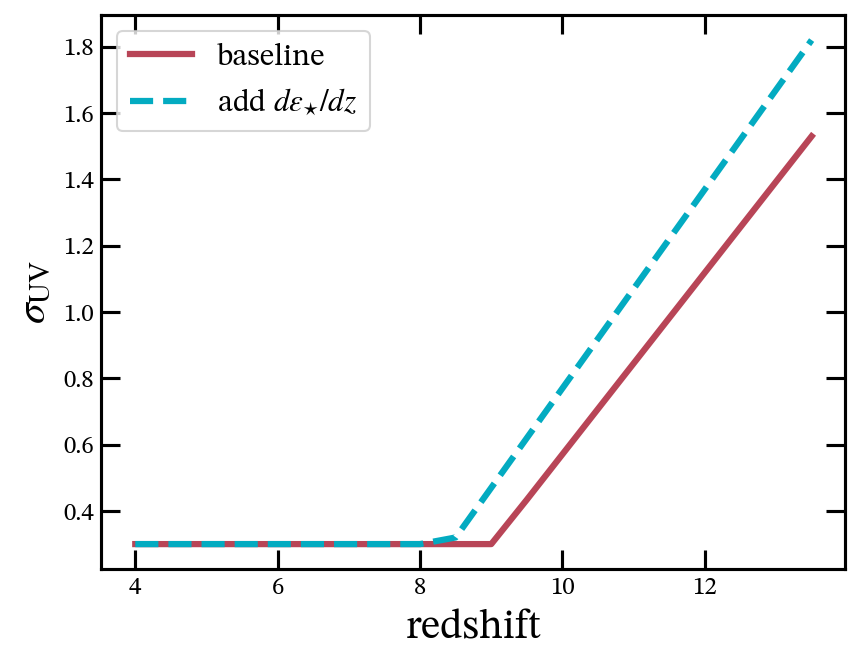

In [ ]:
['baseline', r'add $d\epsilon_{\star}/dz$']dsigdz_plot = eplots.sigma_over_z(UVLFs[1], [dsigdz_fit, add_deps_fit], , zs = np.arange(4, 14, 0.5), Mh = 10)

In [45]:
dsigdz_plot.savefig('/Users/eb35267/Desktop/code/chains/build_model/compare_sig_add_dedz.png')

# Compare UVLF

In [80]:
dsigdz_fit = [0.583, -0.84, 12.006, 0, -0.742, 0, 0.023, 0.274]
add_deps_fit = [0.553, -0.865, 11.945, 0, -0.851, -0.04, 0.17, 0.3]
add_dMdz_fit = [0.534, -0.785, 12.259, 0.09, -0.724, 0, 0.227, 0.298]

piecewise_epsilon =[0.549, -0.947, 12.059, 0, [-0.711, -0.719, -0.731, -0.741, -0.842, -0.833, -0.7, -0.422, -0.384], 0, 0.3, 0]
piecewise_sigma = [0.549, -0.947, 12.059, 0, -0.745, 0, [0.324, 0.375, 0.32, 0.3, 0.3, 0.3, 0.495, 1.079, 1.15], 0]

In [128]:
comparison_params = eMCMC.build_param_data({'dsigdz':{'fit':True}, 'dlogedz':{'fit':True}, 'dlogMcdz':{'fit':True}})

In [129]:
comparison_UVLF = eMCMC.UVLF(sorted_data, comparison_params)

0.5
0.5
0.5
0.5
0.5
0.25
0.25
0.25
0.25
0.5
0.5
0.5
0.5
0.5
0.25
0.25
0.25
0.25
0.5
0.5
0.5
0.5
0.5
0.25
0.25
0.25
0.25
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25


/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:242: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5)
/Users/eb35267/Desktop/code/home/escripts/eplots.py:242: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5)


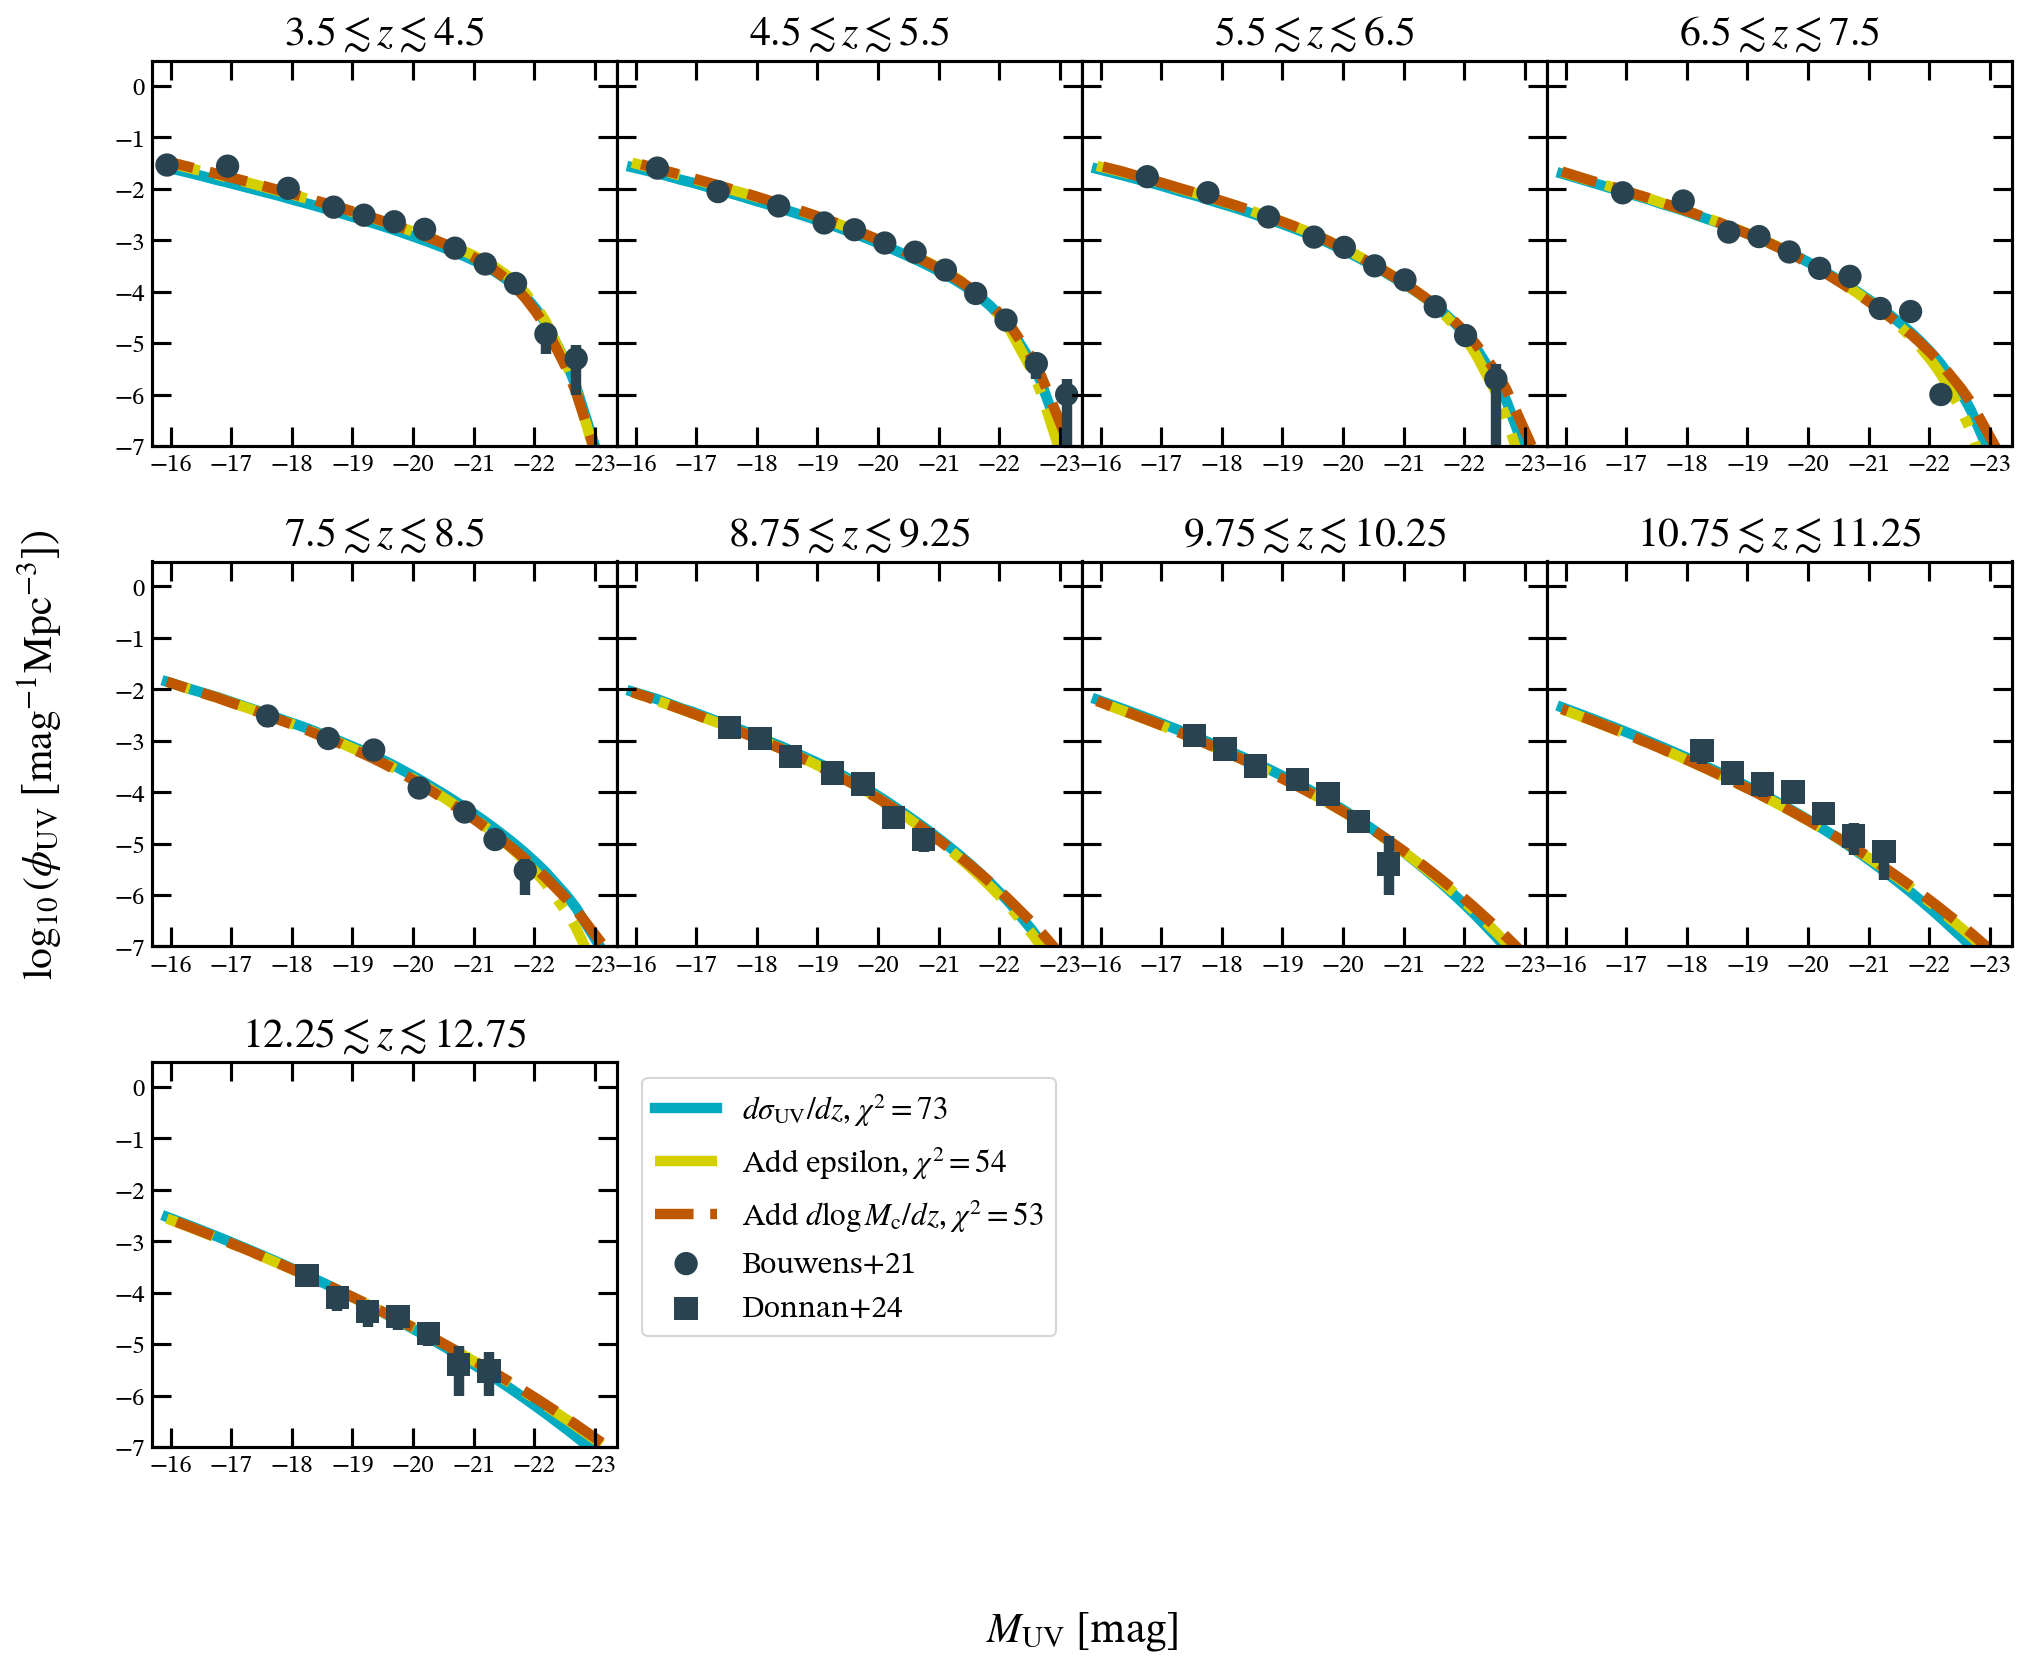

In [136]:
UVLF_fig = eplots.evolving_UVLF_fit(comparison_UVLF, plot_from_chain = False, comparison_fits = [dsigdz_fit, add_deps_fit, add_dMdz_fit], 
                                    comparison_labels = [r'$d\sigma_{\rm{UV}}/dz$', r'Add epsilon', r'Add $d\log M_{\rm{c}}/dz$'])

In [63]:
UVLF_fig.savefig('/Users/eb35267/Desktop/code/chains/UVLF_comparison_eps_Mc.png')

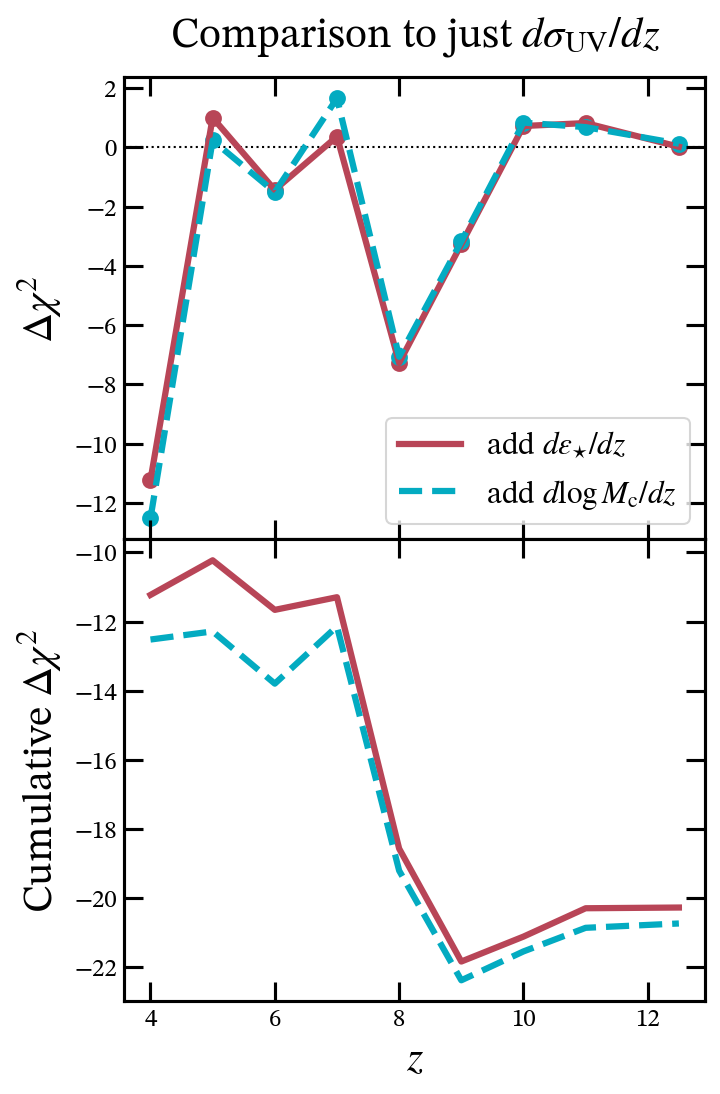

In [71]:
delta_plot = eplots.delta_chi2(comparison_UVLF, dsigdz_fit, r'just $d\sigma_{\rm{UV}}/dz$', [add_deps_fit, add_dMdz_fit], labels = [r'add $d\epsilon_{\star}/dz$', r'add $d\log M_{\rm{c}}/dz$'], )

In [72]:
delta_plot.savefig('/Users/eb35267/Desktop/code/chains/delta_chisq_eps_vs_Mc.png')

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


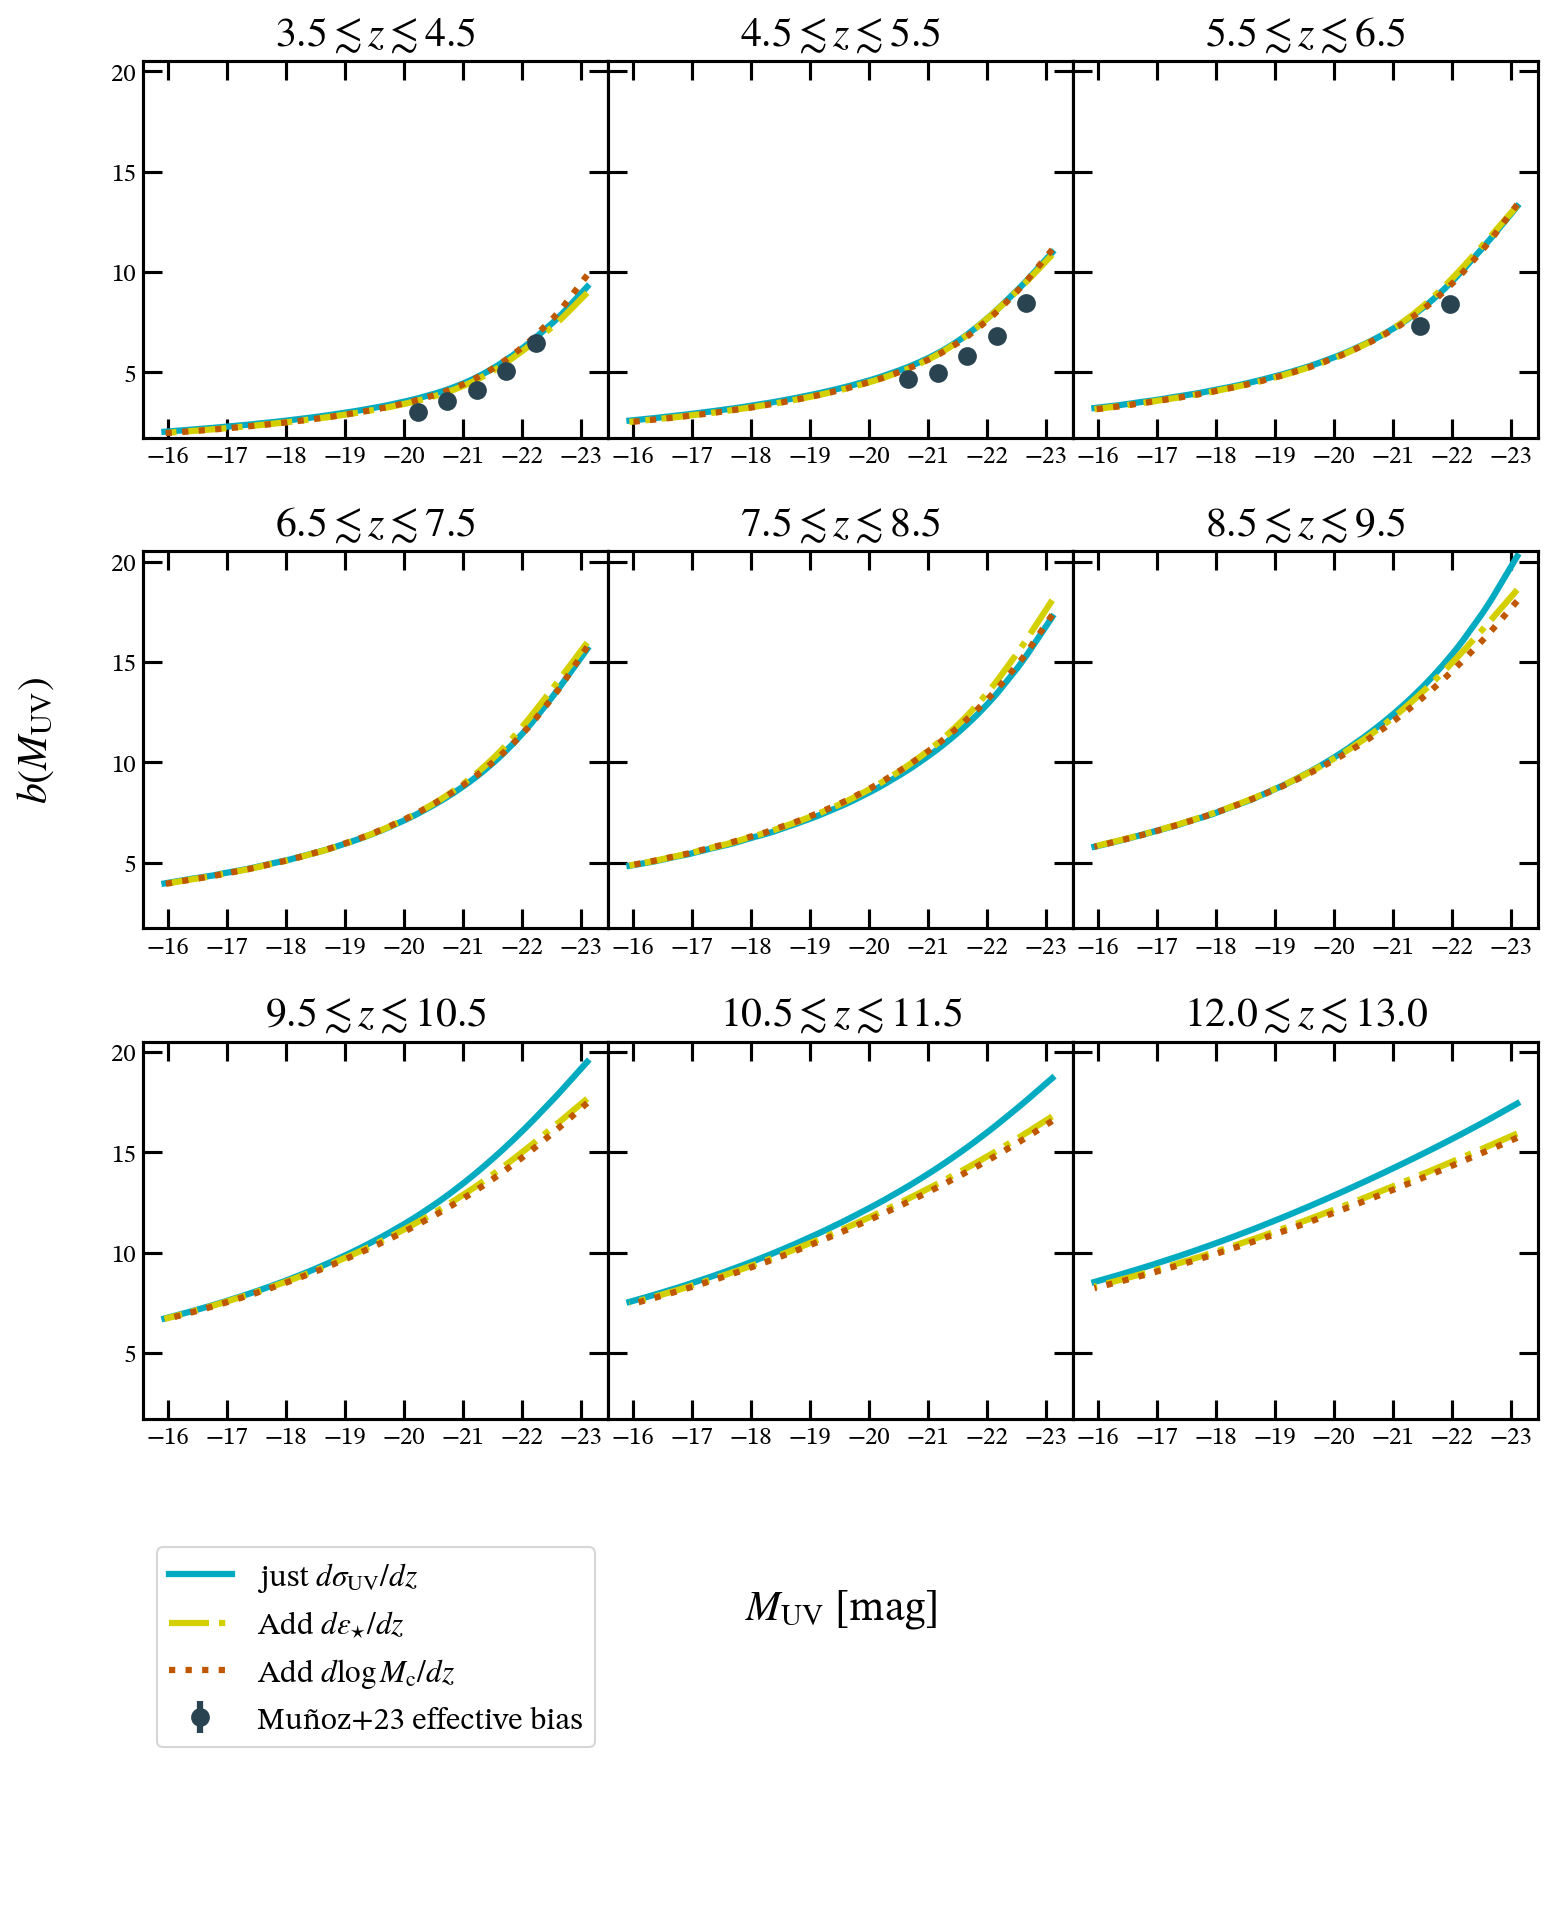

In [76]:
bias_comparison = eplots.bias(comparison_UVLF, compare_fits = [dsigdz_fit, add_deps_fit, add_dMdz_fit], fit_labels = [r'just $d\sigma_{\rm{UV}}/dz$', r'Add $d\epsilon_{\star}/dz$', r'Add $d\log M_{\rm{c}}/dz$'])

In [77]:
bias_comparison.savefig('/Users/eb35267/Desktop/code/chains/bias_eps_M.png')

# Compare SFE(Mh, z) for different models

In [119]:
def sfe_shape_diff_z(my_UVLF, comparison_fits, fit_labels, zs = None, Mhtab = None):
    """
    Plot SFE vs. halo mass at different redshifts
    Inputs:
        my_UVLF [eMCMC UVLF object]: UVLF object used for its methods such as applying time evolution to parameter values & wrapping them in the
                                        right format for zeus21
        param_values [1darray]: values of parameters to calculate SFE
        zs [1darray]: redshifts to plot
        Mhtab [1darray]: log10(Mh) to plot over
        id_max [bool]: Whether or not to identify the maximum SFE at the highest and lowest redshift bin
    Returns:
        fig: A figure showing the SFE over the range of given halo masses & redshifts
    """

    if zs is None:
        zs = np.arange(4, 16, 2)

    if Mhtab is None: 
        Mhtab = np.linspace(9, 13, 200)

    fig = plt.figure(figsize=(6, 4.5))            
    ax_rect  = [0.10, 0.12, 0.78, 0.80]       # left, bottom, width, height (0-1)
    cax_rect = [0.895, 0.12, 0.04, 0.80]      # narrow right slot for cbar
    ax = fig.add_axes(ax_rect)

    if len(zs)>1:
        cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.yellow, eplots.turquoise], zs)

    linestyles = ['solid', 'dashed']
    
    for z in zs:
        for param_values, ls in zip(comparison_fits, linestyles):
            # Calculate parameters at this z
            params = my_UVLF.time_evolution(param_values, z)
            Astro_Parameters = my_UVLF.param_wrapper(params)

        
            # Calculate SFE
            SFEs = my_UVLF.CosmoParams.OmegaM/my_UVLF.CosmoParams.OmegaB * zeus21.sfrd.fstarofz(
                Astro_Parameters, my_UVLF.CosmoParams, z, 10**Mhtab)
            # Assign color
            if len(zs) > 1:
                frac = (z - min(zs)) / (max(zs) - min(zs))
                color = cmap(frac)
            else:
                color = eplots.yellow
            # Plot
            plt.plot(Mhtab, SFEs, color = color, ls = ls, zorder = 0)

    if len(zs)>1:
    # Color bar things:
        cax = fig.add_axes(cax_rect)
        cbar = fig.colorbar(sm, cax=cax, boundaries=boundaries, ticks=zs, aspect = 14)
        cbar.set_label(r'$z$')

    # Labels
    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$f_{\star} = \dot M_{\star} / \dot M_{\rm{gas}}$')
    ax.set_yscale('log')

    for fit_label, ls in zip(fit_labels, linestyles):
        ax.plot(10, 1e-1, label = fit_label, ls = ls, color = 'black')

    
    ax.legend()
        
    return fig 


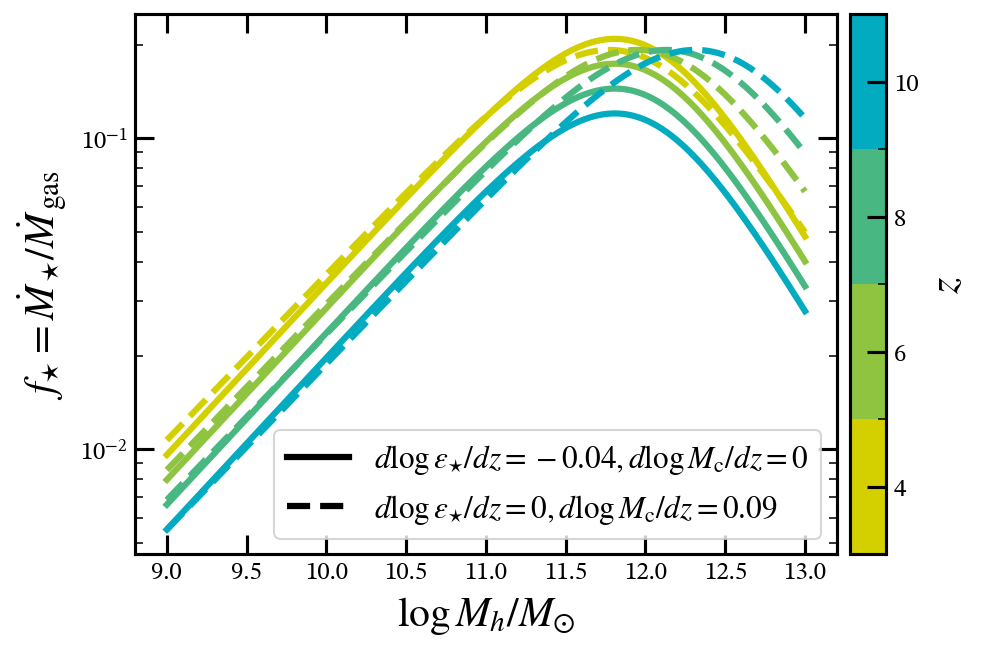

In [122]:
sfe_comparison = sfe_shape_diff_z(comparison_UVLF, [add_deps_fit, add_dMdz_fit], fit_labels = [r'$d\log \epsilon_{\star}/dz = -0.04, d\log M_{\rm{c}}/dz = 0$', 
                                                                                     r'$d\log \epsilon_{\star}/dz = 0, d\log M_{\rm{c}}/dz = 0.09$'], zs = np.arange(4, 12, 2))

In [123]:
sfe_comparison.savefig('/Users/eb35267/Desktop/code/chains/compare_sfe_eps_Mc.png')